In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Import from intervalinf
from intervalinf import IntervalDomain, Function

# Set up plotting
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## 1. Creating Functions on Domains

The simplest way to create a function: just pass a domain and a callable.

### Core API Usage:

In [2]:
# Create a domain
domain = IntervalDomain(0, 1, boundary_type='closed')

# Create a function on that domain
f = Function(domain, evaluate_callable=lambda x: x**2, name="f(x) = x²")

# Evaluate the function
f(0.5)  # Returns 0.25

# Check if attached to a space
f.is_attached  # Returns False (standalone mode)

False

In [3]:
# Create several example functions
domain = IntervalDomain(0, 2*np.pi, boundary_type='closed')

functions = [
    Function(domain, evaluate_callable=lambda x: np.sin(x), name="sin(x)"),
    Function(domain, evaluate_callable=lambda x: np.cos(x), name="cos(x)"),
    Function(domain, evaluate_callable=lambda x: x**2, name="x²"),
    Function(domain, evaluate_callable=lambda x: np.exp(-x), name="e^(-x)"),
]

print("Created Functions:")
print("="*50)
for func in functions:
    print(f"  {func.name:12s} - Domain: {func.function_domain}, Attached: {func.is_attached}")

# Evaluate at a point
x_test = np.pi / 2
print(f"\nEvaluation at x = π/2:")
for func in functions:
    value = func(x_test)
    print(f"  {func.name:12s}: {value:.6f}")

Created Functions:
  sin(x)       - Domain: [0.0, 6.283185307179586], Attached: False
  cos(x)       - Domain: [0.0, 6.283185307179586], Attached: False
  x²           - Domain: [0.0, 6.283185307179586], Attached: False
  e^(-x)       - Domain: [0.0, 6.283185307179586], Attached: False

Evaluation at x = π/2:
  sin(x)      : 1.000000
  cos(x)      : 0.000000
  x²          : 2.467401
  e^(-x)      : 0.207880


### Visualization:

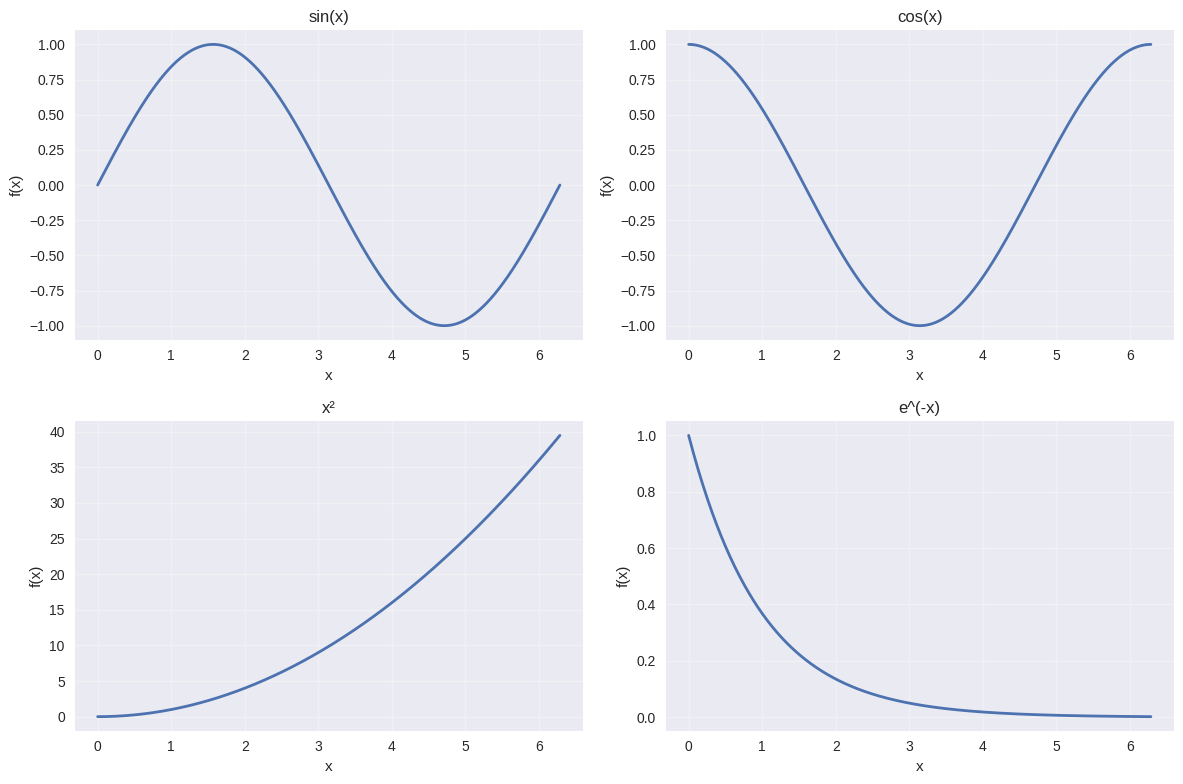

In [4]:
# Plot all functions
x = np.linspace(0, 2*np.pi, 500)

plt.figure(figsize=(12, 8))
for i, func in enumerate(functions):
    y = func(x)  # Can call function directly or use func.evaluate(x)
    plt.subplot(2, 2, i+1)
    plt.plot(x, y, linewidth=2)
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.title(func.name)
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Function Properties and Evaluation

Functions have several useful properties and evaluation methods.

### Core API Usage:

In [5]:
# Create a function
domain = IntervalDomain(-1, 1, boundary_type='closed')
f = Function(domain, evaluate_callable=lambda x: x**3 - x, name="x³ - x")

# Access properties
f.name                  # "x³ - x"
f.function_domain       # IntervalDomain(-1, 1)
f.is_attached          # False

# Evaluate at single point
f(0.5)

# Evaluate at array of points
x_array = np.array([0.0, 0.5, 1.0])
f(x_array)

array([ 0.   , -0.375,  0.   ])

### Detailed Examples:

Function Evaluation Methods:
Polynomial     : f(1.0) = 0.000000 (both methods equivalent: True)
Gaussian       : f(1.0) = 0.367879 (both methods equivalent: True)
Damped sine    : f(1.0) = -0.352769 (both methods equivalent: True)

Array Evaluation:
x values: [-2. -1.  0.  1.  2.]
Polynomial     : [-18.  -4.   0.   0.   2.]
Gaussian       : [0.01831564 0.36787944 1.         0.36787944 0.01831564]
Damped sine    : [ 0.07362525  0.35276853  0.         -0.35276853 -0.07362525]


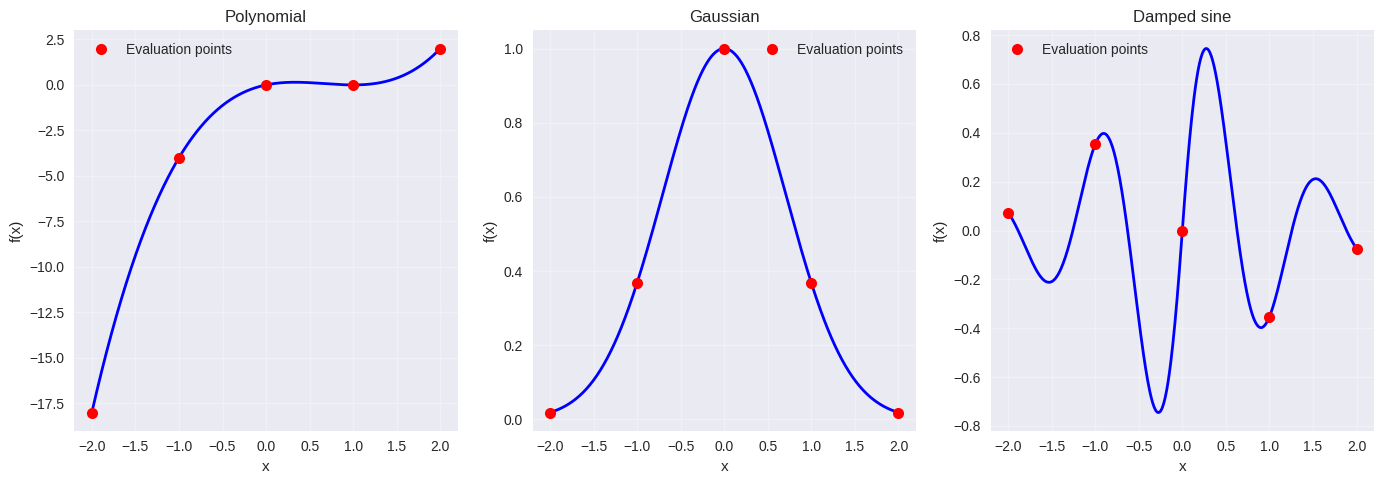

In [ ]:
domain = IntervalDomain(-2, 2, boundary_type='closed')

# Different function types
polynomial = Function(domain, evaluate_callable=lambda x: x**3 - 2*x**2 + x, name="Polynomial")
exponential = Function(domain, evaluate_callable=lambda x: np.exp(-x**2), name="Gaussian")
oscillatory = Function(domain, evaluate_callable=lambda x: np.sin(5*x) * np.exp(-abs(x)), name="Damped sine")

functions = [polynomial, exponential, oscillatory]

# Demonstrate different evaluation methods
print("Function Evaluation Methods:")
print("="*60)

x_test = 1.0
for func in functions:
    # Method 1: Direct call (preferred)
    value1 = func(x_test)

    # Method 2: Explicit evaluate method
    value2 = func.evaluate(x_test)

    print(f"{func.name:15s}: f({x_test}) = {value1:.6f} (both methods equivalent: {np.isclose(value1, value2)})")

# Array evaluation
print("\nArray Evaluation:")
x_array = np.linspace(-2, 2, 5)
print(f"x values: {x_array}")
for func in functions:
    y_array = func(x_array)
    print(f"{func.name:15s}: {y_array}")

# Visualization
x_fine = np.linspace(-2, 2, 500)

plt.figure(figsize=(14, 5))
for i, func in enumerate(functions):
    plt.subplot(1, 3, i+1)
    y = func(x_fine)
    plt.plot(x_fine, y, 'b-', linewidth=2)

    # Mark evaluation points
    y_eval = func(x_array)
    plt.plot(x_array, y_eval, 'ro', markersize=8, label='Evaluation points')

    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.title(func.name)
    plt.grid(True, alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.show()

## 3. Function Integration

Functions can be integrated over their domain using the `integrate()` method.

### Core API Usage:

In [7]:
# Create a function
domain = IntervalDomain(0, 1, boundary_type='closed')
f = Function(domain, evaluate_callable=lambda x: x**2, name="x²")

# Integrate over the domain
result = f.integrate()  # Uses Simpson's rule by default

# Specify integration method
result_trapz = f.integrate(method='trapz', n_points=1000)
result_adaptive = f.integrate(method='adaptive')

# Integration with weight function
result_weighted = f.integrate(weight=lambda x: np.exp(-x))

### Detailed Integration Examples:

In [ ]:
# Test functions with known integrals
domain = IntervalDomain(0, 1, boundary_type='closed')

test_functions = {
    'x²': (lambda x: x**2, 1/3),
    'x³': (lambda x: x**3, 1/4),
    'sin(πx)': (lambda x: np.sin(np.pi * x), 2/np.pi),
    'e^x': (lambda x: np.exp(x), np.e - 1),
}

print("Integration Accuracy Test:")
print("="*80)
print(f"{'Function':15s} | {'Analytical':>12s} | {'Computed':>12s} | {'Error':>12s}")
print("-"*80)

for name, (func_def, analytical) in test_functions.items():
    f = Function(domain, evaluate_callable=func_def, name=name)
    computed = f.integrate(method='simpson', n_points=1000)
    error = abs(computed - analytical)

    print(f"{name:15s} | {analytical:12.6f} | {computed:12.6f} | {error:12.2e}")

# Test different integration methods
print("\nIntegration Method Comparison:")
print("="*80)
f = Function(domain, evaluate_callable=lambda x: np.sin(np.pi * x), name="sin(πx)")
analytical = 2/np.pi

methods = ['simpson', 'trapz', 'adaptive']
for method in methods:
    if method == 'adaptive':
        result = f.integrate(method=method)
    else:
        result = f.integrate(method=method, n_points=1000)
    error = abs(result - analytical)
    print(f"  {method:10s}: {result:.8f}  (error: {error:.2e})")

Integration Accuracy Test:
Function        |   Analytical |     Computed |        Error
--------------------------------------------------------------------------------
x²              |     0.333333 |     0.333333 |     0.00e+00
x³              |     0.250000 |     0.250000 |     2.51e-13
sin(πx)         |     0.636620 |     0.636620 |     1.64e-12
e^x             |     1.718282 |     1.718282 |     1.23e-13

Integration Method Comparison:
  simpson   : 0.63661977  (error: 1.64e-12)
  trapz     : 0.63661925  (error: 5.25e-07)
  adaptive  : 0.63661977  (error: 0.00e+00)


## 4. Weighted Integration

Functions can be integrated with weight functions: ∫ f(x) w(x) dx.

### Core API Usage:

In [9]:
# Create a function
domain = IntervalDomain(0, 1, boundary_type='closed')
f = Function(domain, evaluate_callable=lambda x: x**2)

# Integrate with weight
result = f.integrate(weight=lambda x: np.exp(-x))

# This computes: ∫₀¹ x² e^(-x) dx

### Visualization of Weighted Integration:

Weighted Integration:
Function: sin(πx)
Domain: [0.0, 2.0]

Results:
  w(x) = 1            : -0.000000
  w(x) = x            : -0.636620
  w(x) = e^(-x)       : 0.249910
  w(x) = 1/(1+x²)     : 0.303439


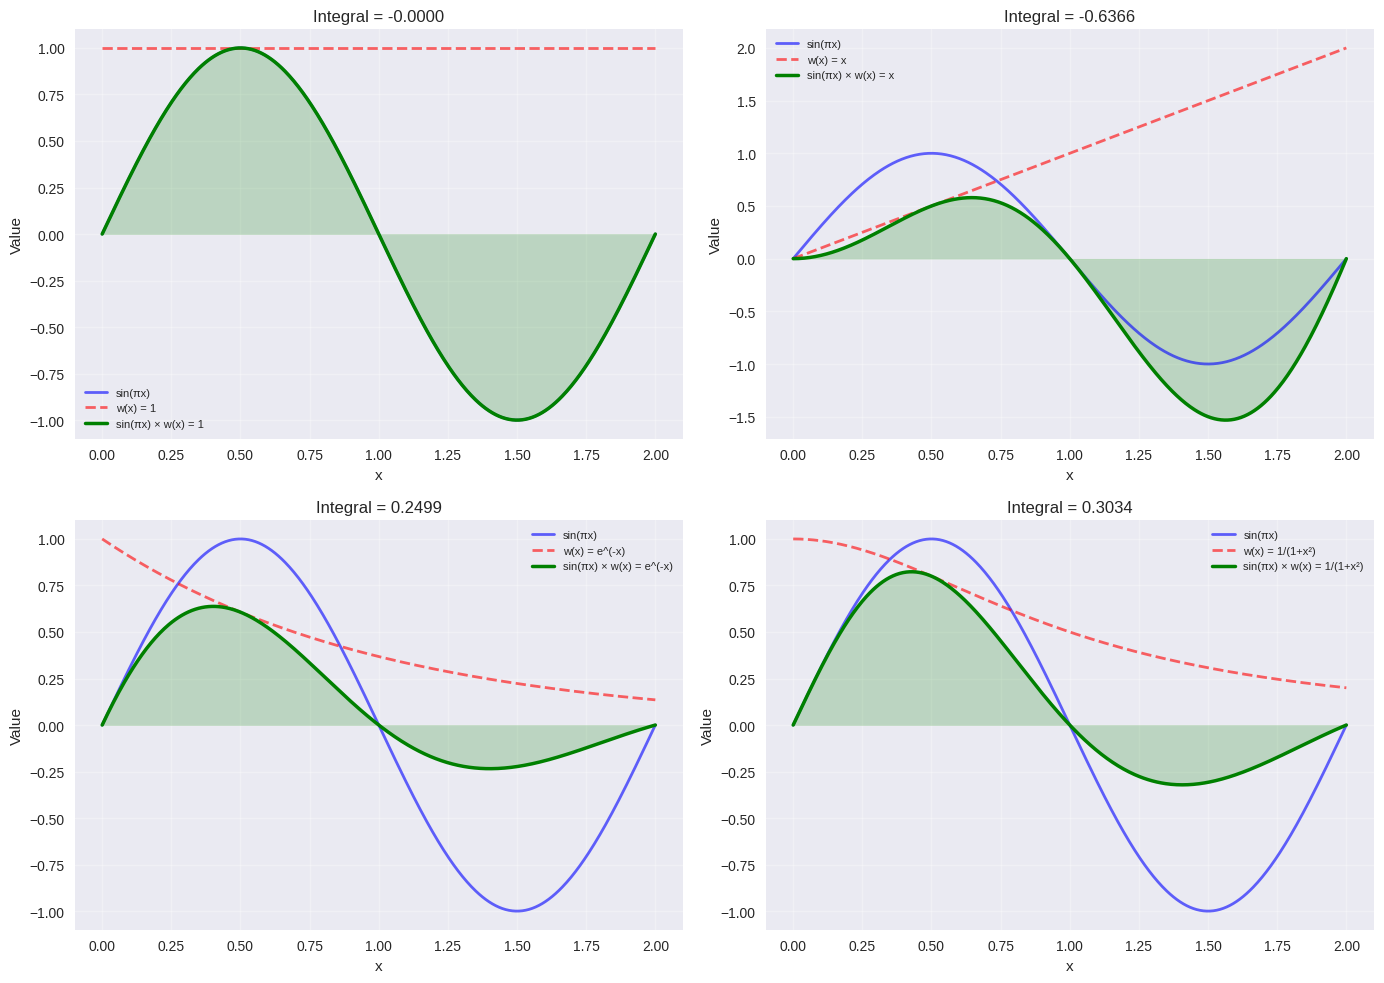

In [ ]:
domain = IntervalDomain(0, 2, boundary_type='closed')

# Function to integrate
f = Function(domain, evaluate_callable=lambda x: np.sin(np.pi * x), name="sin(πx)")

# Different weight functions
weights = [
    (lambda x: np.ones_like(x), "w(x) = 1"),
    (lambda x: x, "w(x) = x"),
    (lambda x: np.exp(-x), "w(x) = e^(-x)"),
    (lambda x: 1 / (1 + x**2), "w(x) = 1/(1+x²)"),
]

print("Weighted Integration:")
print("="*60)
print(f"Function: {f.name}")
print(f"Domain: {domain}")
print("\nResults:")

x = np.linspace(0, 2, 500)
fx = f(x)

plt.figure(figsize=(14, 10))

for i, (weight, weight_name) in enumerate(weights):
    # Compute weighted integral
    result = f.integrate(weight=weight, method='simpson', n_points=1000)
    print(f"  {weight_name:20s}: {result:.6f}")

    # Plot
    plt.subplot(2, 2, i+1)

    wx = weight(x)
    integrand = fx * wx

    plt.plot(x, fx, 'b-', linewidth=2, label=f.name, alpha=0.6)
    plt.plot(x, wx, 'r--', linewidth=2, label=weight_name, alpha=0.6)
    plt.plot(x, integrand, 'g-', linewidth=2.5, label=f'{f.name} × {weight_name}')
    plt.fill_between(x, 0, integrand, alpha=0.2, color='green')

    plt.xlabel('x')
    plt.ylabel('Value')
    plt.title(f'Integral = {result:.4f}')
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Functions with Compact Support

Functions can have compact support (nonzero only on a subset of the domain).

### Core API Usage:

In [11]:
# Create a function with compact support
domain = IntervalDomain(0, 2, boundary_type='closed')

# Function is nonzero only on [0.5, 1.5]
f = Function(
    domain,
    evaluate_callable=lambda x: np.sin(np.pi * x),
    support=(0.5, 1.5),
    name="sin(πx) with support [0.5, 1.5]"
)

# Outside support, function returns 0
f(0.2)    # Returns 0.0
f(1.0)    # Returns sin(π)
f(1.8)    # Returns 0.0

# Check if function has compact support
f.has_compact_support  # Returns True

True

### Examples with Multiple Support Regions:

Functions with Compact Support:

Single support [0.5, 1.5]:
  Domain: [0.0, 3.0]
  Support: [(0.5, 1.5)]
  Has compact support: True
  Test evaluations:
    f(0.1) = 0.0000
    f(0.6) = 1.0000
    f(1.2) = 1.0000
    f(1.7) = 0.0000
    f(2.8) = 0.0000

Two disjoint supports:
  Domain: [0.0, 3.0]
  Support: [(0.2, 0.8), (1.5, 2.2)]
  Has compact support: True
  Test evaluations:
    f(0.1) = 0.0000
    f(0.6) = 0.9511
    f(1.2) = 0.0000
    f(1.7) = 0.5878
    f(2.8) = 0.0000

Three disjoint supports:
  Domain: [0.0, 3.0]
  Support: [(0.0, 0.5), (1.0, 1.5), (2.0, 2.5)]
  Has compact support: True
  Test evaluations:
    f(0.1) = 0.0100
    f(0.6) = 0.0000
    f(1.2) = 1.4400
    f(1.7) = 0.0000
    f(2.8) = 0.0000


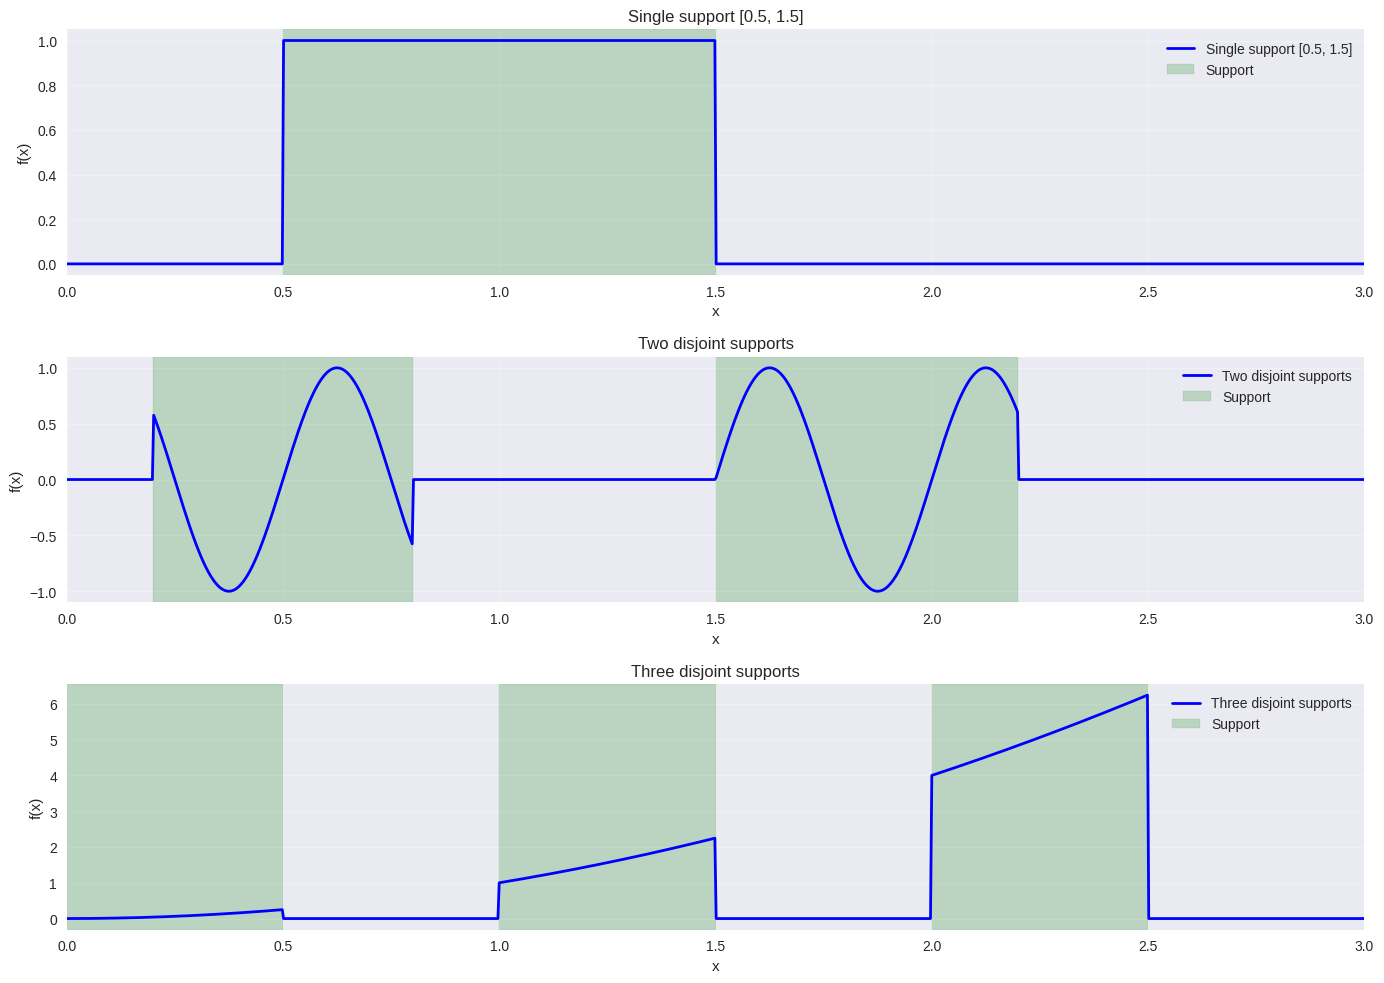

In [ ]:
domain = IntervalDomain(0, 3, boundary_type='closed')

# Create functions with different support configurations
functions_with_support = [
    Function(
        domain,
        evaluate_callable=lambda x: np.ones_like(x),
        support=(0.5, 1.5),
        name="Single support [0.5, 1.5]"
    ),
    Function(
        domain,
        evaluate_callable=lambda x: np.sin(4*np.pi*x),
        support=[(0.2, 0.8), (1.5, 2.2)],
        name="Two disjoint supports"
    ),
    Function(
        domain,
        evaluate_callable=lambda x: x**2,
        support=[(0.0, 0.5), (1.0, 1.5), (2.0, 2.5)],
        name="Three disjoint supports"
    ),
]

print("Functions with Compact Support:")
print("="*60)
for func in functions_with_support:
    print(f"\n{func.name}:")
    print(f"  Domain: {func.function_domain}")
    print(f"  Support: {func.support}")
    print(f"  Has compact support: {func.has_compact_support}")

    # Test evaluation inside and outside support
    test_points = [0.1, 0.6, 1.2, 1.7, 2.8]
    print(f"  Test evaluations:")
    for x in test_points:
        y = func(x)
        print(f"    f({x:.1f}) = {y:.4f}")

# Visualize
x = np.linspace(0, 3, 1000)

plt.figure(figsize=(14, 10))

for i, func in enumerate(functions_with_support):
    plt.subplot(3, 1, i+1)

    y = func(x)
    plt.plot(x, y, 'b-', linewidth=2, label=func.name)

    # Highlight support regions
    for support_interval in func.support:
        a, b = support_interval
        plt.axvspan(a, b, alpha=0.2, color='green', label='Support' if support_interval == func.support[0] else '')

    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.title(func.name)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 3)

plt.tight_layout()
plt.show()

## 6. Function Arithmetic

Functions support arithmetic operations: addition, subtraction, multiplication, and scalar operations.

### Core API Usage:

In [13]:
# Create functions
domain = IntervalDomain(0, 1, boundary_type='closed')
f = Function(domain, evaluate_callable=lambda x: x**2, name="x²")
g = Function(domain, evaluate_callable=lambda x: np.sin(np.pi * x), name="sin(πx)")

# Addition
h1 = f + g  # Creates new function: x² + sin(πx)

# Subtraction
h2 = f - g  # Creates new function: x² - sin(πx)

# Multiplication
h3 = f * g  # Creates new function: x² × sin(πx)

# Scalar multiplication
h4 = 2 * f  # Creates new function: 2x²
h5 = f * 3  # Creates new function: 3x²

# Scalar addition
h6 = f + 1  # Creates new function: x² + 1

### Detailed Arithmetic Examples:

Function Arithmetic:

Evaluation at x = 0.5:
  f(x)           : 0.250000
  g(x)           : -1.000000
  f + g          : -0.750000
  f - g          : 1.250000
  f × g          : -0.250000
  2f + 0.5g      : 0.000000


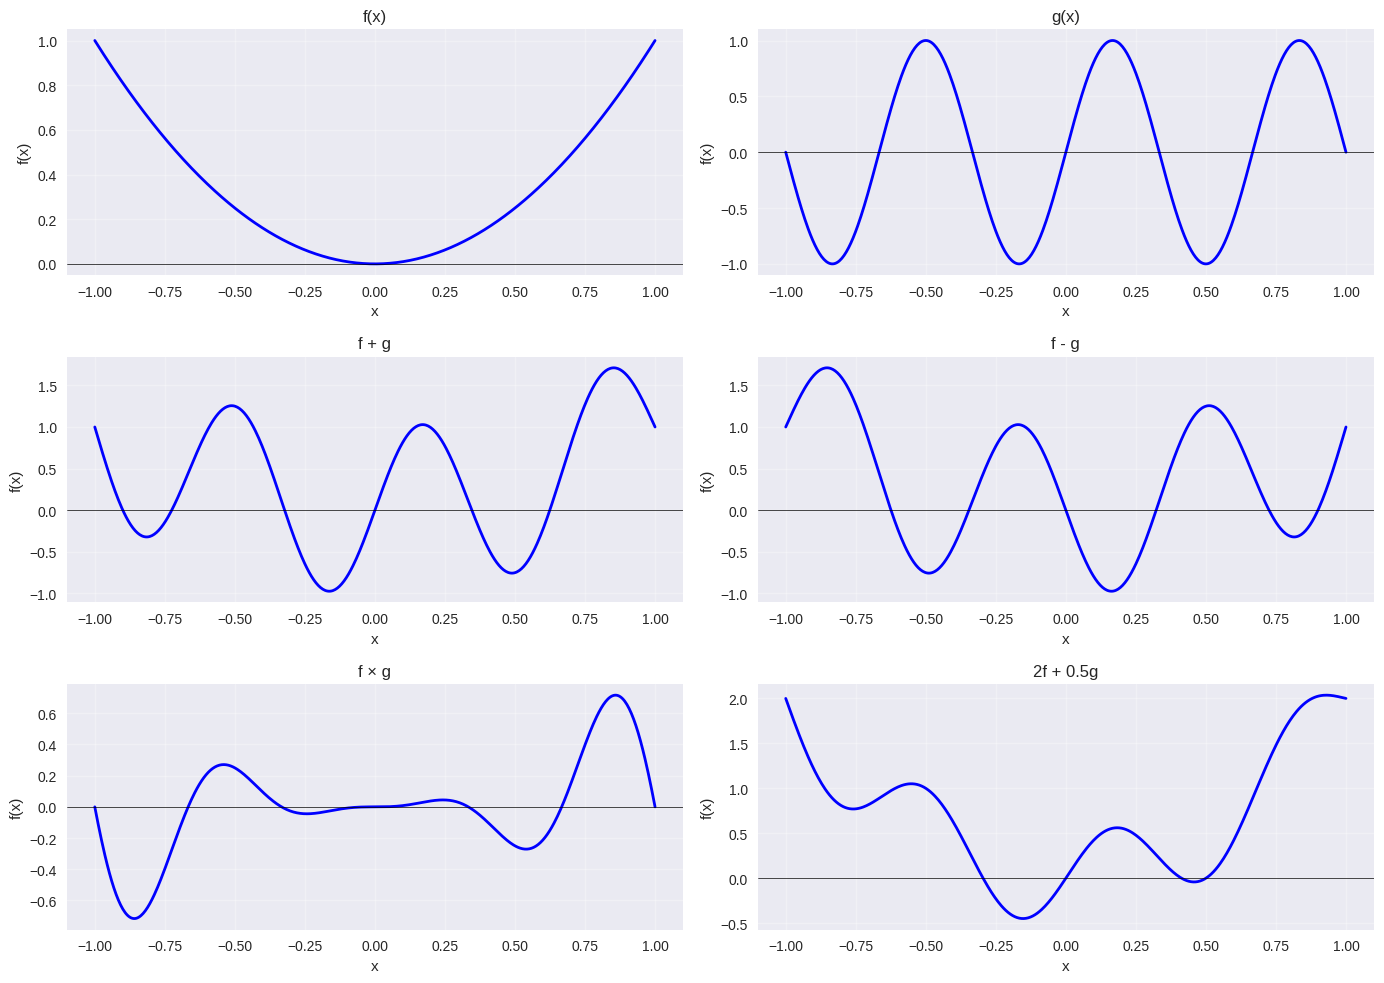


Integration of Combined Functions:
  ∫ (f(x)) dx = 0.666667
  ∫ (g(x)) dx = 0.000000
  ∫ (f + g) dx = 0.666667
  ∫ (f - g) dx = 0.666667
  ∫ (f × g) dx = 0.000000
  ∫ (2f + 0.5g) dx = 1.333333


In [14]:
domain = IntervalDomain(-1, 1, boundary_type='closed')

# Base functions
f = Function(domain, evaluate_callable=lambda x: x**2, name="f(x) = x²")
g = Function(domain, evaluate_callable=lambda x: np.sin(3*np.pi*x), name="g(x) = sin(3πx)")

# Create combinations
combinations = [
    (f, "f(x)"),
    (g, "g(x)"),
    (f + g, "f + g"),
    (f - g, "f - g"),
    (f * g, "f × g"),
    (2 * f + 0.5 * g, "2f + 0.5g"),
]

print("Function Arithmetic:")
print("="*60)

x_test = 0.5
print(f"\nEvaluation at x = {x_test}:")
for func, description in combinations:
    value = func(x_test)
    print(f"  {description:15s}: {value:.6f}")

# Visualize
x = np.linspace(-1, 1, 500)

plt.figure(figsize=(14, 10))

for i, (func, description) in enumerate(combinations):
    plt.subplot(3, 2, i+1)
    y = func(x)
    plt.plot(x, y, 'b-', linewidth=2)
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.title(description)
    plt.grid(True, alpha=0.3)
    plt.axhline(0, color='k', linewidth=0.5)

plt.tight_layout()
plt.show()

# Integration of combined functions
print("\nIntegration of Combined Functions:")
print("="*60)
for func, description in combinations:
    integral = func.integrate(method='simpson', n_points=1000)
    print(f"  ∫ ({description}) dx = {integral:.6f}")

## 7. Plotting Functions

Functions have a built-in `plot()` method for quick visualization.

### Core API Usage:

<Axes: title={'center': 'Function on [0.0, 6.283185307179586]'}, xlabel='x', ylabel='f(x)'>

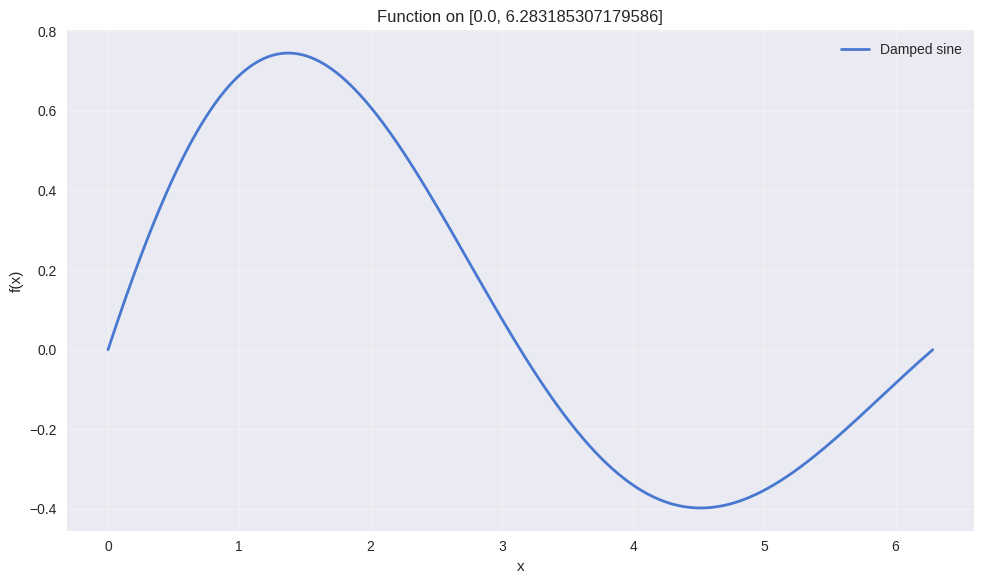

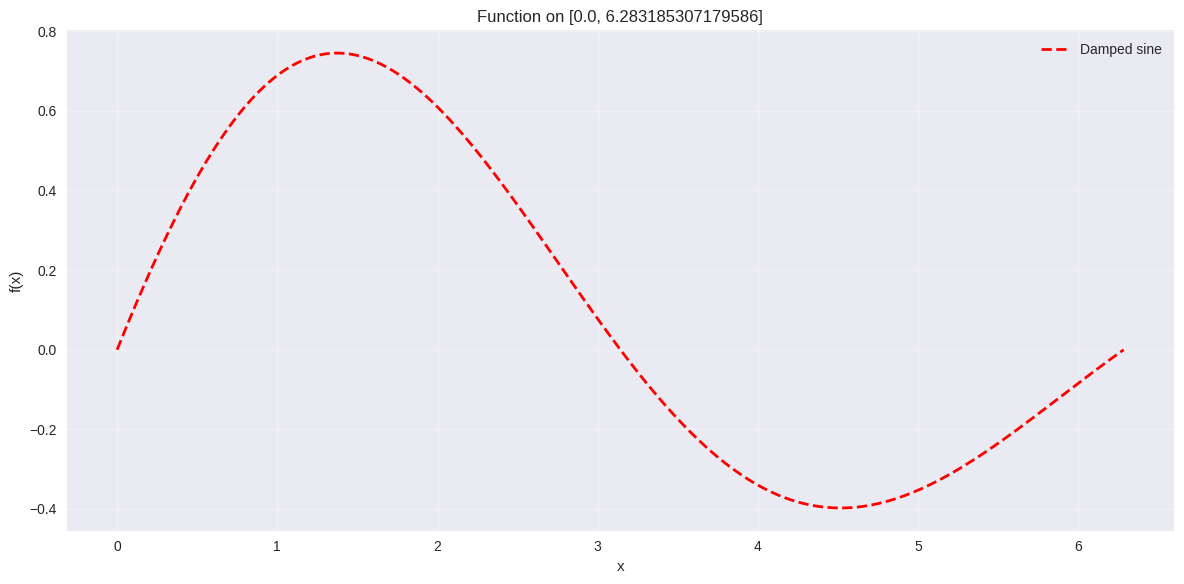

In [15]:
# Create a function
domain = IntervalDomain(0, 2*np.pi, boundary_type='closed')
f = Function(domain, evaluate_callable=lambda x: np.sin(x) * np.exp(-0.2*x), name="Damped sine")

# Simple plot
f.plot()

# Plot with custom settings
f.plot(n_points=500, figsize=(12, 6), color='red', linestyle='--')

### Multiple Function Plots:

Using built-in plot() method:
  Plotting sin(x)...


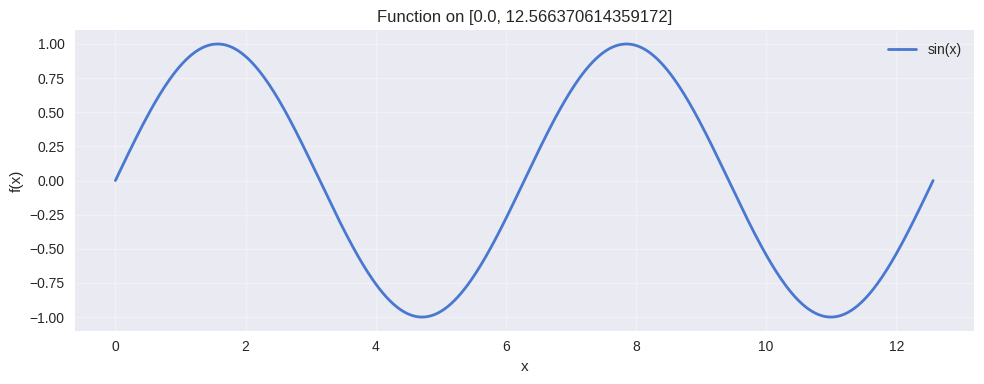

  Plotting Damped sine...


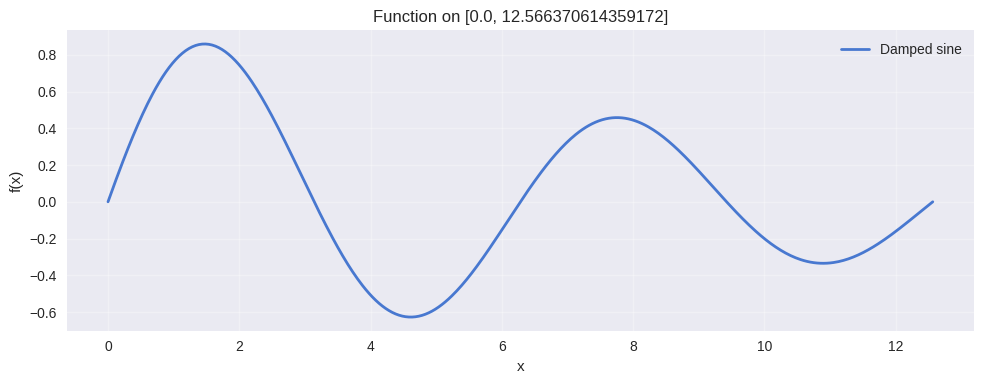

  Plotting Modulated sine...


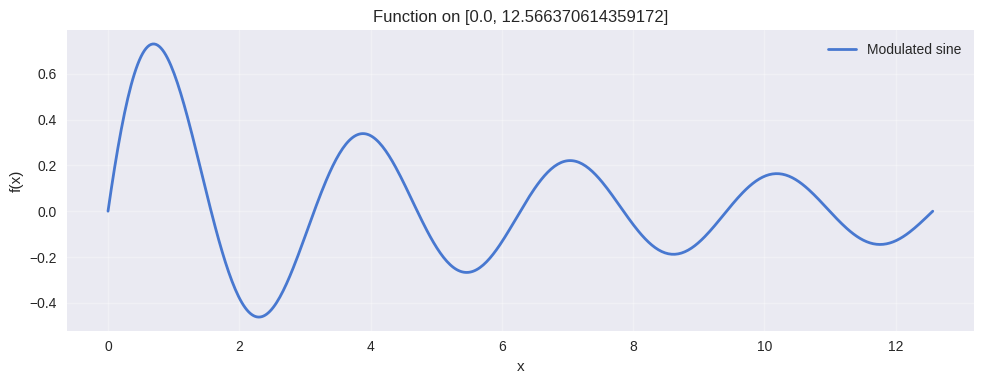

In [16]:
# Create interesting functions
domain = IntervalDomain(0, 4*np.pi, boundary_type='closed')

functions = [
    Function(domain, evaluate_callable=lambda x: np.sin(x), name="sin(x)"),
    Function(domain, evaluate_callable=lambda x: np.sin(x) * np.exp(-0.1*x), name="Damped sine"),
    Function(domain, evaluate_callable=lambda x: np.sin(2*x) / (1 + 0.5*x), name="Modulated sine"),
]

# Plot each individually using the built-in method
print("Using built-in plot() method:")
for func in functions:
    print(f"  Plotting {func.name}...")
    func.plot(n_points=500, figsize=(10, 4))
    plt.show()

## 8. Copying Functions

Functions can be copied to create independent instances.

### Core API Usage:

In [17]:
# Create a function
domain = IntervalDomain(0, 1, boundary_type='closed')
f = Function(domain, evaluate_callable=lambda x: x**2, name="original")

# Create a copy
f_copy = f.copy()

# Modify the copy's name
f_copy.name = "copy"

# Original is unchanged
print(f"Original: {f.name}")
print(f"Copy: {f_copy.name}")

Original: original
Copy: copy


## 9. Summary

The `Function` class in `intervalinf` provides a powerful and flexible way to work with functions on interval domains:

### Key Features:

1. **Standalone mode**: Create functions without needing a function space
   ```python
   f = Function(domain, evaluate_callable=lambda x: x**2)
   ```

2. **Simple evaluation**: Call functions like regular Python callables
   ```python
   y = f(x)  # Works for scalars and arrays
   ```

3. **Integration**: Built-in numerical integration with multiple methods
   ```python
   result = f.integrate(method='simpson')
   result_weighted = f.integrate(weight=lambda x: np.exp(-x))
   ```

4. **Compact support**: Specify regions where function is nonzero
   ```python
   f = Function(domain, evaluate_callable=..., support=(a, b))
   ```

5. **Function arithmetic**: Combine functions with +, -, ×, scalar operations
   ```python
   h = 2*f + g - 1
   ```

6. **Easy plotting**: Built-in visualization method
   ```python
   f.plot()
   ```

### What's Next:

- **Function Spaces**: See the next notebook for working with Lebesgue and Sobolev spaces
- **Basis Representations**: Learn about coefficient-based functions in Hilbert spaces
- **Operators**: Explore differential operators and spectral methods

The standalone function mode provides a clean, simple API for mathematical computations without the overhead of function space machinery when you don't need it!